# Example Notebook Assignment 5

In this notebook we give you a working implementation of a domain model in L2-Python. We focus again on the domain of loneliness (see description in assignment 4). A graphical overview of the model is provided in Figure 1. this notebook serves as an example for the analysis model you need to implement for assignment 5.

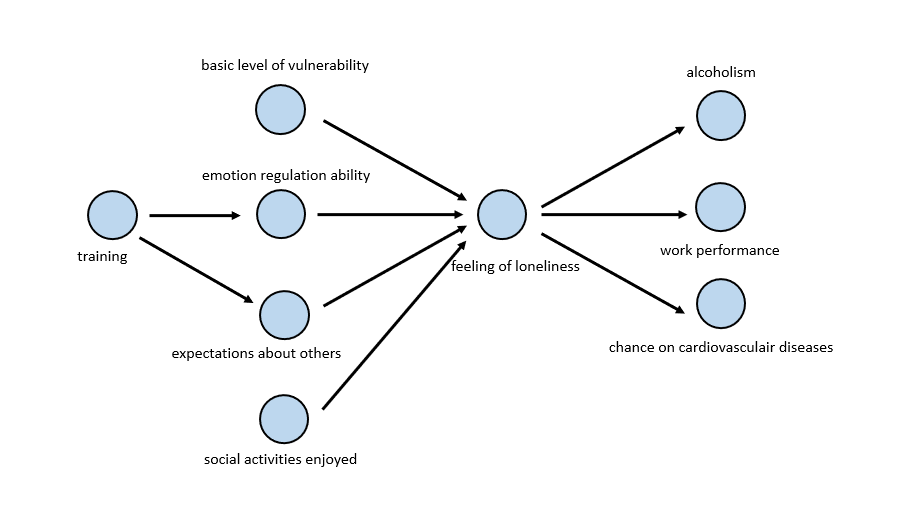

**Figure 1.** Graphical notation of domain model for loneliness.

The concepts used in Figure 1 are formalised below in Table 1 and their sorts are formalised in Table 2.

**Table 1.** Formalization of concepts for the loneliness model.
***
**Concept** | **Description of use** | **Formalization**
---- |-----|----
Training  |  Receiving of training to improve personal traits  |  training(A: AGENT, B:BOOLEAN)  
Emotion regulation ability   |  Ability to regulate one’s emotions in certain circumstances. The higher its value the better a person is at regulating their emotions.   |  emotion_regulation_ability(A: AGENT, R:REAL)
Expectations about others   |  The expectation the person has of others in their surroundings. The higher its value the more rejective the person’s interpretations are   |  expectations_of_others(A: AGENT, R:REAL)
Level of vulnerability   |  Vulnerability of a person to social disconnection   |  level_of_vulnerability(A: AGENT, L:LEVEL)
Social activities   |  Number of total social activities a person participates in in total   |  social_activities_enjoyed(A: AGENT, R:REAL) 
Feeling of loneliness   |  Whether the person feels lonely or not   |  feeling_of_loneliness(A: AGENT, B:BOOLEAN)   
Work performance   |  Quality of the work that is performed by the person   |  performance_at_work(A: AGENT, P:PERFORMANCE)  
Alcoholism   |  Amount of alcohol consumed by the person in a short period of time   |  alcoholism(A: AGENT, R:REAL)   
Cardiovascular diseases   |  Presence of cardio vascular diseases in the person   |  chance_cardio_disease(A: AGENT, B:BOOLEAN)  

**Table 1.** Formalization of sorts for the loneliness model.
***
**Sort** | **Description of use** | **Elements**
---- |-----|----
B:BOOLEAN  |  Qualification of training, feeling of loneliness and presence of cardiovascular diseases  |  True, False 
L:LEVEL   |  The degree of alcoholism and change on cardio-vascular diseases   |  low, medium, high
P:PERFORMANCE   |  The degree of work performance   |  good, sufficient, unsufficient, bad
R:REAL  |  Quantifications of emotion regulation ability, expectations about others, social and activities   |  All real values

## Implementation

#### Imports
Before we write the rules, we first import the Predicate class, just as we did in assignment 3.

In [2]:
import os

# To avoid issues with "Run All" button
if not(str(os.getcwd()).split("\\")[-1] == "base folder"):
    os.chdir(str(os.getcwd()) + "\\base folder")

from state import Predicate
import inspect

#### Sorts


In [3]:
%%writefile sorts.txt
AGENT;         {agent_happy, agent_normal, agent_sad}
PERFORMANCE;   {good, sufficient, insufficient, bad}
LEVEL;         {low, medium, high}

Overwriting sorts.txt


#### Predicates


In [4]:
%%writefile predicates.txt
feeling_of_loneliness;        {AGENT, REAL}
emotion_regulation_ability;   {AGENT, REAL}
expectation_about_others;     {AGENT, REAL}
social_activities_enjoyed;    {AGENT, REAL}
level_of_alcoholism;           {AGENT, LEVEL}
performance_at_work;          {AGENT, PERFORMANCE}
chance_of_cardiovascular_diseases; {AGENT, LEVEL}
training;                     {AGENT, BOOLEAN}
level_of_vulnerability;       {AGENT, REAL}
desire;                       {PREDICATE}

Overwriting predicates.txt


#### Scenario


In [5]:
%%writefile scenarios.txt
feeling_of_loneliness{agent_happy, 0.5}; [1]
emotion_regulation_ability{agent_happy, 0.2}; [1]
expectation_about_others{agent_happy, 0.2}; [1]
social_activities_enjoyed{agent_happy, 0.8}; [1:Inf]
chance_of_cardiovascular_diseases{agent_happy, low}; [1]
training{agent_happy, false}; [1:24]
training{agent_happy, true}; [25:50]
level_of_vulnerability{agent_happy, 0.2}; [1:19]
level_of_vulnerability{agent_happy, 0.4}; [20:Inf]
desire{feeling_of_loneliness{agent_happy, false}}; [1:Inf]

Overwriting scenarios.txt


#### Rules


Rule 1: calculate the value for the concept "expectation about others", based on training

In [6]:
def set_expectation_about_others(states, t):
    """
        set the expectation about others based on training and the emotion regulation ability

        training : [[agent], value]
        emotion_regulation_ability : [[agent1], value]
        expectation_about_others : [[agent], value]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]

    for predicate in previous_state.get_predicate("training"):
        agent = predicate.get_name_agent(0)
        training = predicate.get_value()
        for expectation_about_others in previous_state.get_predicate_by_agent("emotion_regulation_ability", agent):
            expectation_value = expectation_about_others.get_value()
            if training and expectation_value > 0:
                expectation_about_others = expectation_value - 0.1
            else:
                expectation_about_others = expectation_value
            new_predicate = Predicate("expectation_about_others", [agent], expectation_about_others)
            states[t].add_predicate_to_state(new_predicate, rule_name)

Rule 2: calculate new value for concept emotion regulation ability based on training

In [7]:
def set_emotion_regulation_ability(states, t):
    """
        set the emotion regulation ability based on training and the current ability

        training : [[agent], value]
        emotion_regulation_ability : [[agent], value]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]

    for predicate in previous_state.get_predicate("training"):
        agent = predicate.get_name_agent(0)
        training = predicate.get_value()
        for emotion_regulation_ability in previous_state.get_predicate_by_agent("emotion_regulation_ability", agent):
            ability_value = emotion_regulation_ability.get_value()
            if training and 0 < ability_value < 1:
                regulation_ability = ability_value + 0.1
            else:
                regulation_ability = ability_value
            new_predicate = Predicate("emotion_regulation_ability", [agent], regulation_ability)
            states[t].add_predicate_to_state(new_predicate, rule_name)

Rule 3: calculate feeling of loneliness

In [8]:
def set_feeling_of_loneliness(states, t):
    """
        set the feeling of loneliness of an agent based on the level of vulnerability, emotion regulation ability,
        expectation about others and social activities enjoyed


        level_of_vulnerability : [[agent], value]
        emotion_regulation_ability : [[agent], value]
        expectation_about_others : [[agent], value]
        social_activities_enjoyed : [[agent], value]
        feeling_of_loneliness : [[agent], value]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]

    for predicate in previous_state.get_predicate("level_of_vulnerability"):
        agent = predicate.get_name_agent(0)
        vulnerability_level = predicate.get_value()
        regulation_ability, expectation_others, activities_enjoyed = -1, -1, -1
        for regulation_ability in previous_state.get_predicate_by_agent("emotion_regulation_ability", agent):
            regulation_ability = regulation_ability.get_value()
        for expectation_others in previous_state.get_predicate_by_agent("expectation_about_others", agent):
            expectation_others = expectation_others.get_value()
        for activities_enjoyed in previous_state.get_predicate_by_agent("social_activities_enjoyed", agent):
            activities_enjoyed = activities_enjoyed.get_value()
        level_of_loneliness = (vulnerability_level + regulation_ability + expectation_others + activities_enjoyed) / 4
        new_predicate = Predicate("feeling_of_loneliness", [agent], level_of_loneliness)
        states[t].add_predicate_to_state(new_predicate, rule_name)

Rule 4a: helper function for the performance level

In [9]:
PERFORMANCE_GOOD, PERFORMANCE_SUFFICIENT, PERFORMANCE_INSUFFICIENT = 0.8, 0.5, 0.3

def get_performance_level(behaviour_level):
    """
        obtain the performance level based on the behaviour level of the agent and thresholds
    """
    if behaviour_level <= PERFORMANCE_GOOD:
        return "good"
    elif PERFORMANCE_GOOD < behaviour_level <= PERFORMANCE_SUFFICIENT:
        return "sufficient"
    elif PERFORMANCE_SUFFICIENT < behaviour_level <= PERFORMANCE_INSUFFICIENT:
        return "insufficient"
    else:
        return "bad"

Rule 4b: set the performance level

In [10]:
def set_performance_level(states, t):
    """
        set the level of performance at work of an agent based on the feeling of loneliness

        level_of_behaviour : [[agent], value]
        performance_at_work : [[agent], performance]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]
    for predicate in previous_state.get_predicate("feeling_of_loneliness"):
        agent = predicate.get_name_agent(0)
        performance_level = get_performance_level(predicate.get_value())
        new_predicate = Predicate("performance_at_work", [agent], performance_level)
        states[t].add_predicate_to_state(new_predicate, rule_name)

Rule 5a: helper function for the chance of cardio disease

In [11]:
def convert_chance_cardio_disease(value):
    """
        obtain the performance level based on the thresholds
    """
    if value <= LOW_CHANCE_THRESHOLD:
        return "low"
    elif LOW_CHANCE_THRESHOLD < value <= MEDIUM_CHANCE_THRESHOLD:
        return "medium"
    else:
        return "high"

Rule 5b: set the chance of cardio disease

In [12]:
def set_chance_cardio_disease(states, t):
    """
        set the chance of cardiovascular diseases of an agent based on the feeling of loneliness

        physical_level : [[agent], value]
        chance_of_cardiovascular_diseases : [[agent], chance]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]

    for predicate in previous_state.get_predicate("feeling_of_loneliness"):
        agent = predicate.get_name_agent(0)
        physical_level = predicate.get_value()
        chance = convert_chance_cardio_disease(physical_level)
        new_predicate = Predicate("chance_of_cardiovascular_diseases", [agent], chance)
        states[t].add_predicate_to_state(new_predicate, rule_name)

Rule 6a: helper function for the alcoholism level

In [13]:
LOW_CHANCE_THRESHOLD, MEDIUM_CHANCE_THRESHOLD = 0.33, 0.66
def convert_alcoholism_level(alcoholism_level):
    """
        obtain the performance level based on the behaviour level of the agent and thresholds
    """
    if alcoholism_level <= LOW_CHANCE_THRESHOLD:
        return "low"
    elif LOW_CHANCE_THRESHOLD < alcoholism_level <= MEDIUM_CHANCE_THRESHOLD:
        return "medium"
    else:
        return "high"

Rule 6b: set the alcoholism level

In [14]:
def set_alcoholism_level(states, t):
    """
        set the level of alcoholism of an agent based on the feeling of loneliness
        feeling_of_loneliness : [[agent], value]
        level_of_alcoholism : [[agent], level]
    """
    # obtain the name of the rule by using the inspect module
    rule_name = inspect.stack()[0][3]
    previous_state = states[t - 1]

    for predicate in previous_state.get_predicate("feeling_of_loneliness"):
        agent = predicate.get_name_agent(0)
        physical_level = predicate.get_value()
        chance = convert_alcoholism_level(physical_level)
        new_predicate = Predicate("level_of_alcoholism", [agent], chance)
        states[t].add_predicate_to_state(new_predicate, rule_name)

Add all the temporal rules (not the helper functions) to the rule set below.

In [15]:
rules = [set_expectation_about_others, set_emotion_regulation_ability,
         set_feeling_of_loneliness, set_performance_level,
         set_chance_cardio_disease, set_alcoholism_level]

#### Run

First, import the StateMachine & visualization rule

In [16]:
from state_machine import StateMachine
from visualization import run_visualization

Next, define the files, MAX_T and other constants used

In [17]:
MAX_T = 50
scenario = "scenarios.txt"
predicates = "predicates.txt"
sorts = "sorts.txt"


Initialize the StateMachine

In [18]:
StateMachine = StateMachine(predicates, sorts, scenario, MAX_T, rules)

Run the simulation!

In [19]:
StateMachine.run()

#### Visualize

The following predicates will be visualized:
feeling_of_loneliness
emotion_regulation_ability
expectation_about_others
social_activities_enjoyed
chance_of_cardiovascular_diseases
training
level_of_vulnerability
desire_feeling_of_loneliness
performance_at_work
level_of_alcoholism


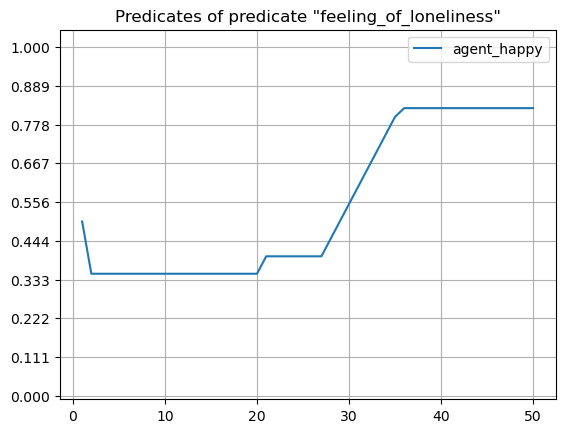

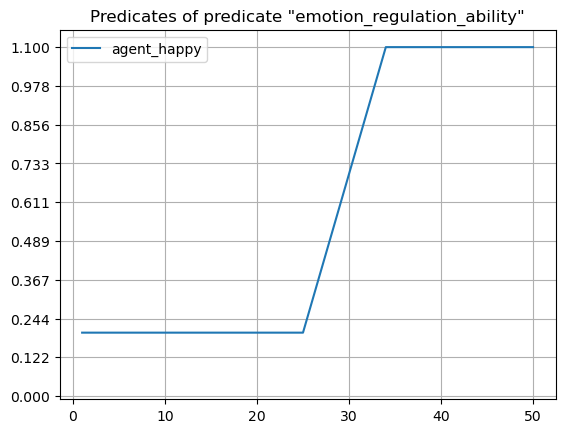

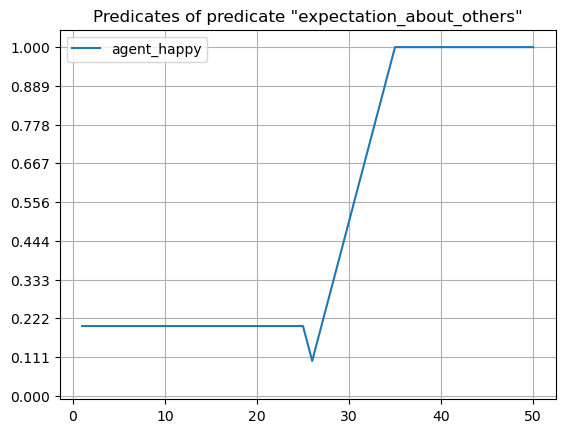

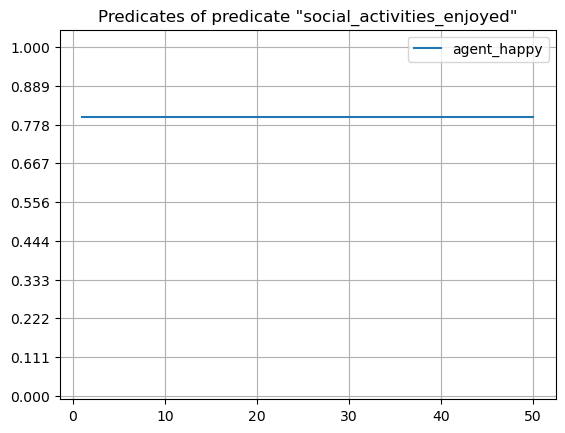

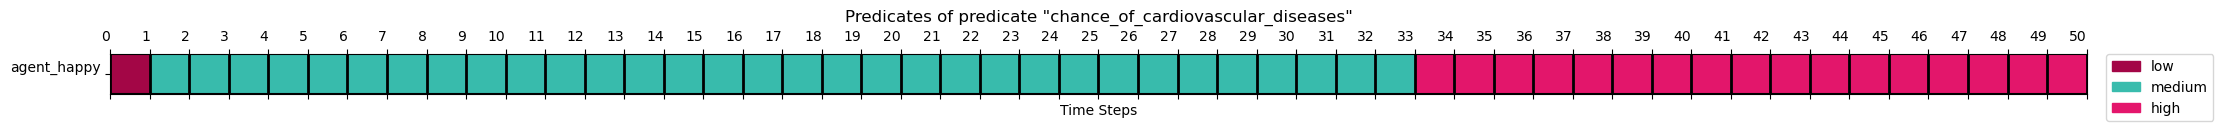

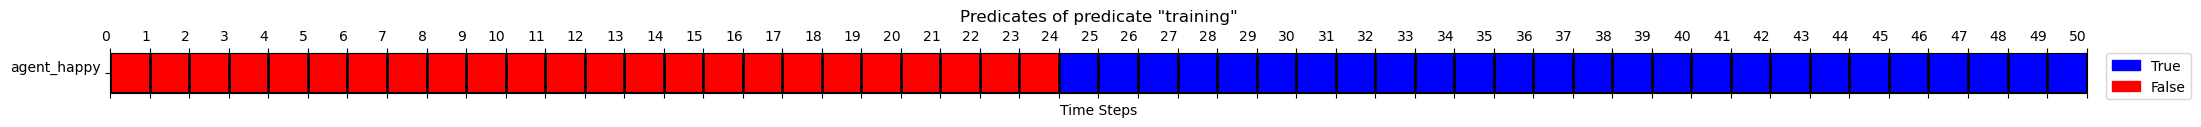

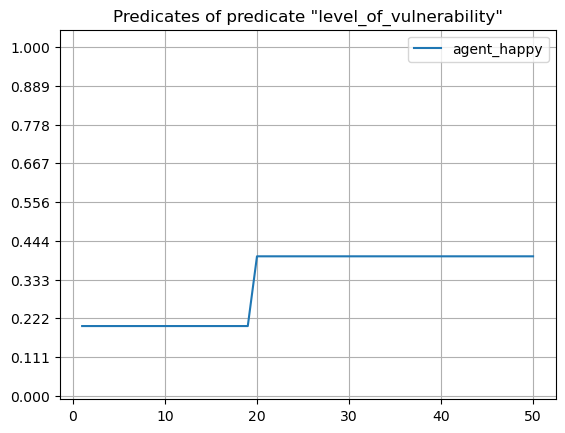

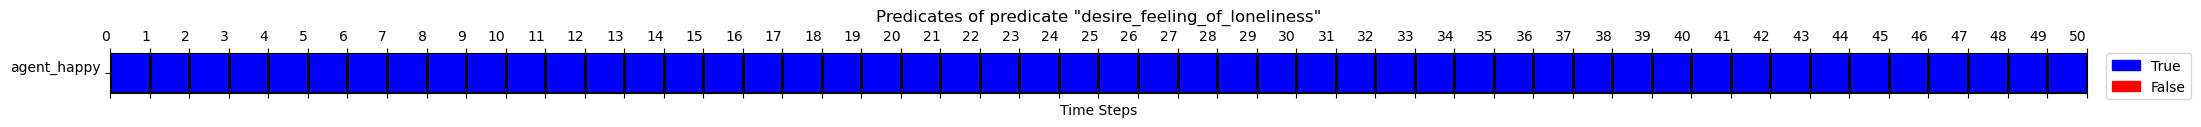

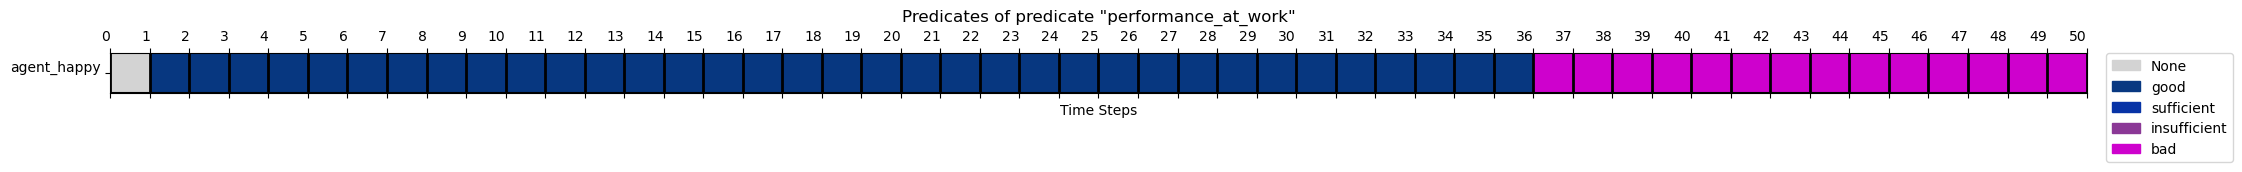

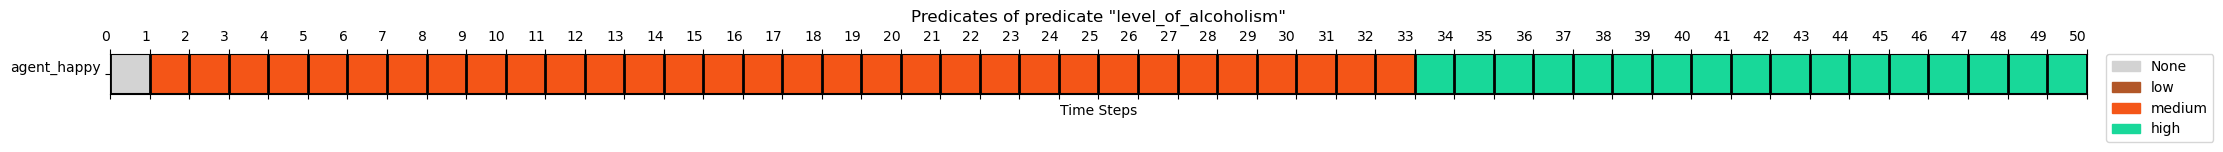

In [20]:
run_visualization(StateMachine)